# 🚦 Traffic Volume Forecasting with LSTM (Deep Learning)
### Dataset: Real Multi-Junction Traffic — Nov 2015 to Jun 2017

This notebook builds an **LSTM (Long Short-Term Memory)** neural network to forecast
hourly vehicle counts for **4 road junctions** using your real `traffic.csv` dataset.

| Step | Description |
|---|---|
| 1 | Install & Import |
| 2 | Load & Explore Data |
| 3 | Feature Engineering |
| 4 | Prepare LSTM Sequences |
| 5 | Build & Train LSTM Model |
| 6 | Evaluate & Visualise |
| 7 | Forecast Next 24 Hours |
| 8 | Save Model |

> ⚡ **Enable GPU** for faster training: Runtime → Change runtime type → T4 GPU


## 📦 Step 1 — Install & Import Libraries

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

print(f"✅ TensorFlow : {tf.__version__}")
print(f"✅ Pandas     : {pd.__version__}")
print(f"✅ Numpy      : {np.__version__}")
gpu = tf.config.list_physical_devices("GPU")
print(f"✅ GPU        : {'Available ✅' if gpu else 'Not found — using CPU'}")


✅ TensorFlow : 2.19.0
✅ Pandas     : 2.2.2
✅ Numpy      : 2.0.2
✅ GPU        : Not found — using CPU


## 📊 Step 2 — Load & Explore the Dataset

Upload your `traffic.csv` file when prompted.
It must contain these columns: `DateTime`, `Junction`, `Vehicles`, `ID`


In [2]:
from google.colab import files

print("📁 Please upload your traffic.csv file:")
uploaded = files.upload()
filename = [k for k in uploaded.keys() if k.endswith('.csv')][0]

df = pd.read_csv(filename)
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values(['Junction', 'DateTime']).reset_index(drop=True)

print(f"\n✅ Loaded {len(df):,} records")
print(f"   Date range : {df['DateTime'].min()} → {df['DateTime'].max()}")
print(f"   Junctions  : {sorted(df['Junction'].unique())}")
print(f"   Columns    : {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(10)


📁 Please upload your traffic.csv file:


Saving traffic.csv to traffic.csv

✅ Loaded 48,120 records
   Date range : 2015-11-01 00:00:00 → 2017-06-30 23:00:00
   Junctions  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   Columns    : ['DateTime', 'Junction', 'Vehicles', 'ID']

Missing values:
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
5,2015-11-01 05:00:00,1,6,20151101051
6,2015-11-01 06:00:00,1,9,20151101061
7,2015-11-01 07:00:00,1,8,20151101071
8,2015-11-01 08:00:00,1,11,20151101081
9,2015-11-01 09:00:00,1,12,20151101091


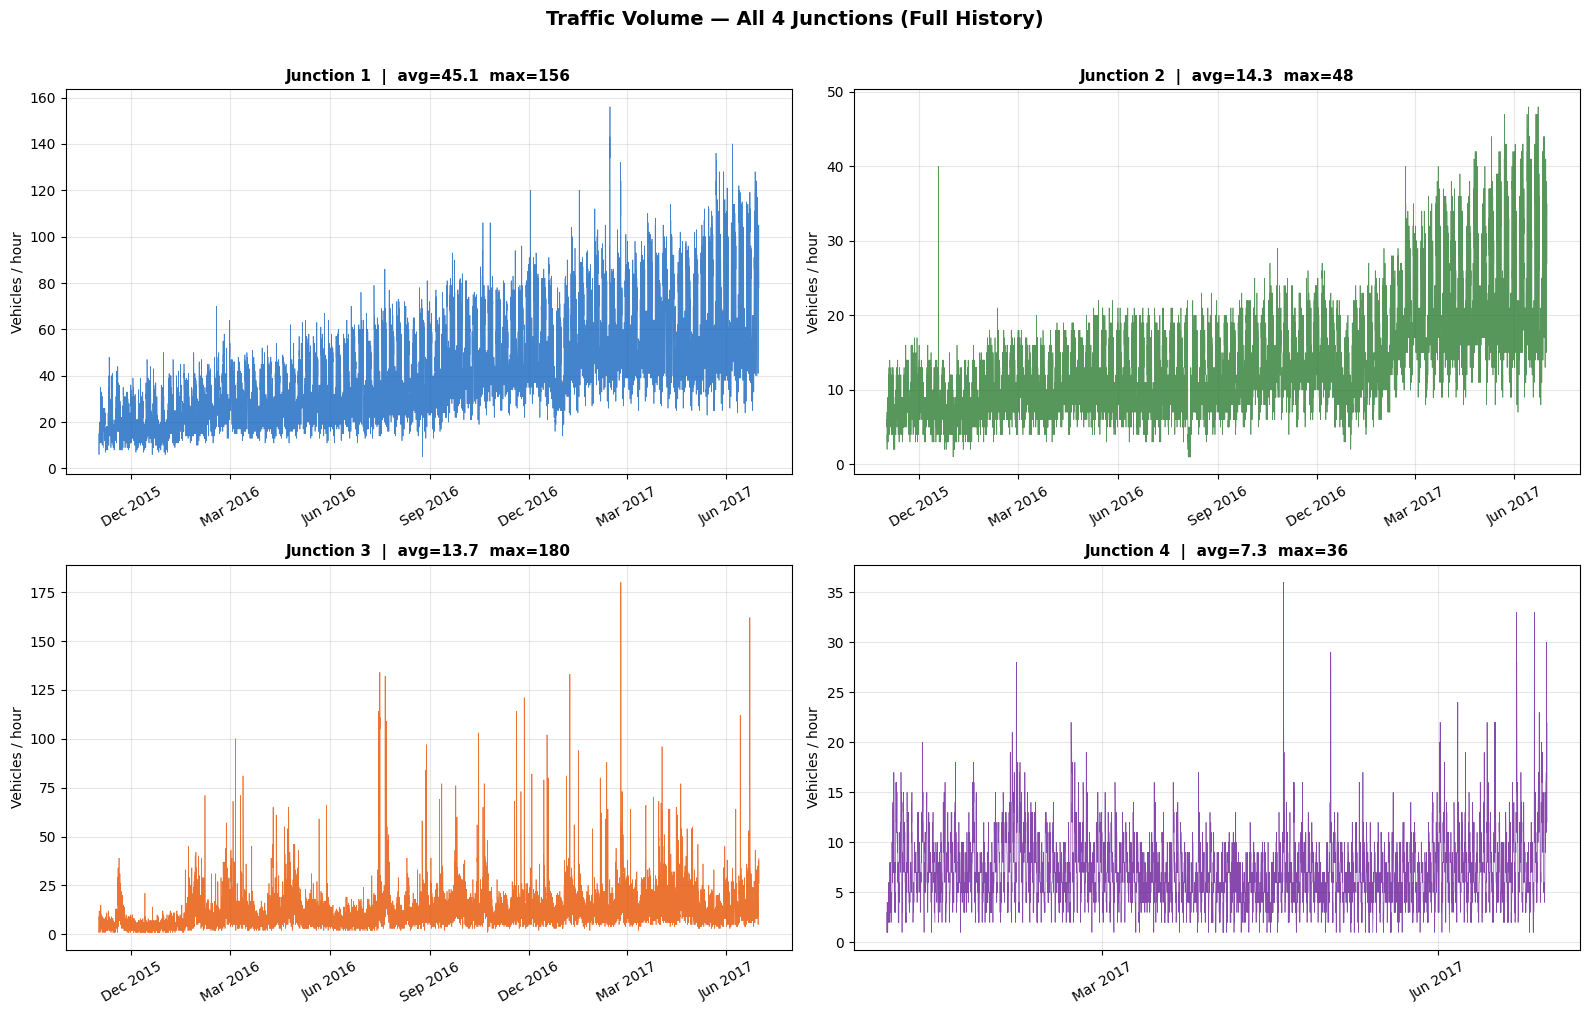

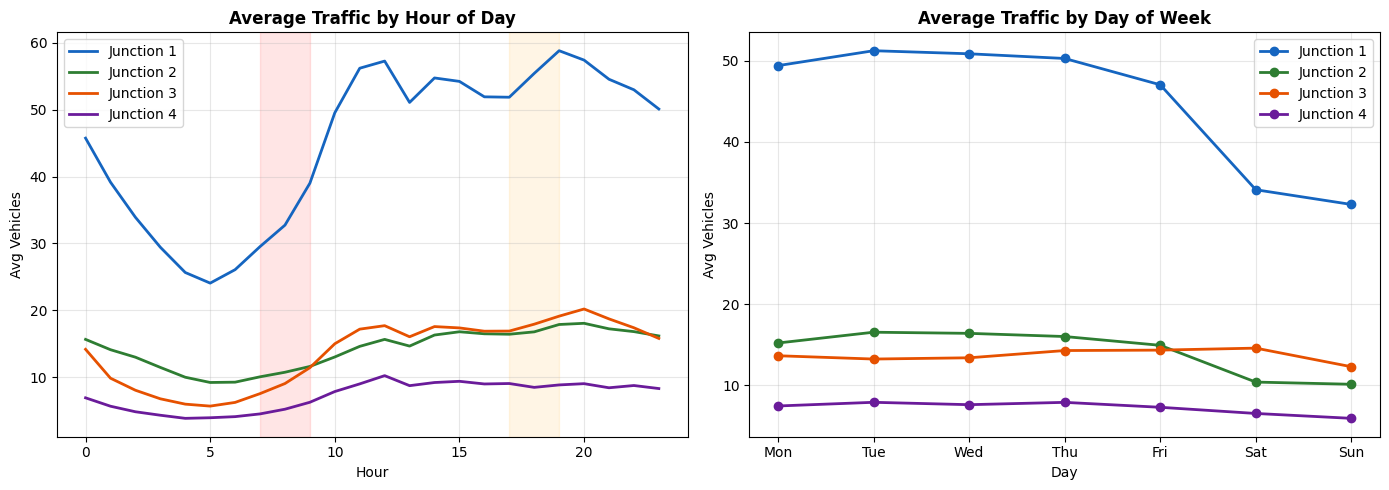

In [3]:
# ── EDA: Traffic patterns per junction ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
junctions = sorted(df['Junction'].unique())
colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

for i, junc in enumerate(junctions):
    jdf = df[df['Junction'] == junc].copy()
    axes[i].plot(jdf['DateTime'], jdf['Vehicles'],
                 linewidth=0.5, color=colors[i], alpha=0.8)
    axes[i].set_title(f'Junction {junc}  |  avg={jdf["Vehicles"].mean():.1f}  max={jdf["Vehicles"].max()}',
                      fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Vehicles / hour')
    axes[i].grid(alpha=0.3)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[i].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Traffic Volume — All 4 Junctions (Full History)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Hourly pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['hour'] = df['DateTime'].dt.hour
df['day_of_week'] = df['DateTime'].dt.dayofweek

for i, junc in enumerate(junctions):
    jdf = df[df['Junction'] == junc]
    hourly = jdf.groupby('hour')['Vehicles'].mean()
    axes[0].plot(hourly.index, hourly.values, label=f'Junction {junc}', color=colors[i], linewidth=2)

axes[0].set_title('Average Traffic by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Avg Vehicles')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].axvspan(7, 9, alpha=0.1, color='red', label='Rush AM')
axes[0].axvspan(17, 19, alpha=0.1, color='orange')

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
for i, junc in enumerate(junctions):
    jdf = df[df['Junction'] == junc]
    daily = jdf.groupby('day_of_week')['Vehicles'].mean()
    axes[1].plot(days, daily.values, label=f'Junction {junc}', color=colors[i], linewidth=2, marker='o')

axes[1].set_title('Average Traffic by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Avg Vehicles')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 🔧 Step 3 — Feature Engineering

We extract **time-based features** and **lag features** to give the LSTM
context about periodicity and recent traffic levels.


In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    df['hour']         = df['DateTime'].dt.hour
    df['day_of_week']  = df['DateTime'].dt.dayofweek
    df['month']        = df['DateTime'].dt.month
    df['day_of_year']  = df['DateTime'].dt.dayofyear
    df['week_of_year'] = df['DateTime'].dt.isocalendar().week.astype(int)
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
    df['is_rush_hour'] = df['hour'].isin([7,8,9,17,18,19]).astype(int)

    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin']= np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']= np.cos(2 * np.pi * df['month'] / 12)

    # Lag features (per junction, so we group)
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        df[f'lag_{lag}h'] = df.groupby('Junction')['Vehicles'].shift(lag)

    # Rolling stats (per junction)
    for w in [3, 6, 24]:
        df[f'roll_mean_{w}h'] = df.groupby('Junction')['Vehicles'].transform(
            lambda x: x.shift(1).rolling(w).mean())
        df[f'roll_std_{w}h']  = df.groupby('Junction')['Vehicles'].transform(
            lambda x: x.shift(1).rolling(w).std())
    df['roll_max_24h'] = df.groupby('Junction')['Vehicles'].transform(
        lambda x: x.shift(1).rolling(24).max())
    df['roll_min_24h'] = df.groupby('Junction')['Vehicles'].transform(
        lambda x: x.shift(1).rolling(24).min())

    df.dropna(inplace=True)
    return df.reset_index(drop=True)

df_feat = engineer_features(df)
FEATURE_COLS = [c for c in df_feat.columns
                if c not in ('DateTime','Junction','Vehicles','ID',
                             'hour','day_of_week','month')]
print(f"✅ Features      : {len(FEATURE_COLS)}")
print(f"✅ Records after dropna: {len(df_feat):,}")
print(f"   Features: {FEATURE_COLS}")


✅ Features      : 26
✅ Records after dropna: 47,448
   Features: ['day_of_year', 'week_of_year', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'roll_mean_3h', 'roll_std_3h', 'roll_mean_6h', 'roll_std_6h', 'roll_mean_24h', 'roll_std_24h', 'roll_max_24h', 'roll_min_24h']


## 🔄 Step 4 — Prepare LSTM Sequences

LSTM needs **3D input**: `(samples, timesteps, features)`

We slide a window of `LOOKBACK` hours to predict `1` hour ahead.
We train **one model per junction** so each road gets a specialised model.


In [5]:
LOOKBACK    = 24   # hours of history to look at
BATCH_SIZE  = 64
EPOCHS      = 80
JUNCTION_TO_TRAIN = 1   # ← change to 1, 2, 3, or 4; or loop all below

def prepare_sequences(jdf: pd.DataFrame, feature_cols: list, lookback: int):
    """Scale data and create sliding-window sequences for LSTM."""
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_raw = scaler_X.fit_transform(jdf[feature_cols])
    y_raw = scaler_y.fit_transform(jdf[['Vehicles']])

    X_seq, y_seq = [], []
    for i in range(lookback, len(X_raw)):
        X_seq.append(X_raw[i-lookback:i])
        y_seq.append(y_raw[i])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    return X_seq, y_seq, scaler_X, scaler_y

# Prepare for selected junction
jdf = df_feat[df_feat['Junction'] == JUNCTION_TO_TRAIN].copy()
X_seq, y_seq, scaler_X, scaler_y = prepare_sequences(jdf, FEATURE_COLS, LOOKBACK)

# Chronological 80/20 split
split = int(len(X_seq) * 0.80)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]
test_dates = jdf['DateTime'].iloc[LOOKBACK + split:].values

print(f"Junction        : {JUNCTION_TO_TRAIN}")
print(f"Lookback window : {LOOKBACK} hours")
print(f"X shape         : {X_seq.shape}  (samples, timesteps, features)")
print(f"Train samples   : {len(X_train):,}")
print(f"Test  samples   : {len(X_test):,}")


Junction        : 1
Lookback window : 24 hours
X shape         : (14400, 24, 26)  (samples, timesteps, features)
Train samples   : 11,520
Test  samples   : 2,880


## 🧠 Step 5 — Build & Train the LSTM Model

Architecture:
- **2 stacked LSTM layers** with dropout to prevent overfitting
- **BatchNormalization** for stable training
- **Early Stopping** to avoid over-training
- **ReduceLROnPlateau** to auto-tune learning rate


In [6]:
def build_lstm(input_shape: tuple) -> tf.keras.Model:
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        BatchNormalization(),

        LSTM(64, return_sequences=False),
        Dropout(0.2),
        BatchNormalization(),

        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

model = build_lstm((LOOKBACK, len(FEATURE_COLS)))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        79,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,649 (514.25 KB)

 Trainable params: 131,265 (512.75 KB)

 Non-trainable params: 384 (1.50 KB)

🚀 Training LSTM for Junction 1...
Epoch 1/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - loss: 0.1626 - mae: 0.3028 - val_loss: 0.0986 - val_mae: 0.2793 - learning_rate: 0.0010
Epoch 2/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0415 - mae: 0.1587 - val_loss: 0.0380 - val_mae: 0.1620 - learning_rate: 0.0010
Epoch 3/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - loss: 0.0224 - mae: 0.1165 - val_loss: 0.0298 - val_mae: 0.1423 - learning_rate: 0.0010
Epoch 4/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0135 - mae: 0.0903 - val_loss: 0.0242 - val_mae: 0.1297 - learning_rate: 0.0010
Epoch 5/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - loss: 0.0091 - mae: 0.0732 - val_loss: 0.0209 - val_mae: 0.1183 - learning_rate: 0.0010
Epoch 6/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - loss: 0.0067 - mae: 0.0627 - val_loss: 0.0148 - val_mae: 0.0981 - learning_rate: 0.0010
Epoch 7/80
180/180 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0055 - mae: 0.0563 - val_loss: 0.0204 

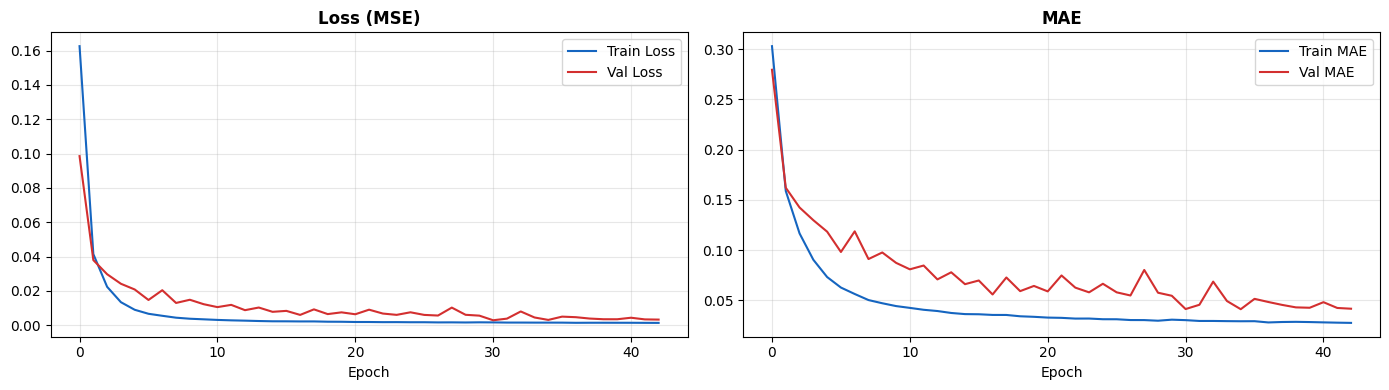

✅ Training complete — best epoch: 31


In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f'best_model_junction{JUNCTION_TO_TRAIN}.keras',
                    monitor='val_loss', save_best_only=True, verbose=0),
]

print(f"🚀 Training LSTM for Junction {JUNCTION_TO_TRAIN}...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train Loss', color='#1565C0')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#D32F2F')
axes[0].set_title('Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', color='#1565C0')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#D32F2F')
axes[1].set_title('MAE', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"✅ Training complete — best epoch: {np.argmin(history.history['val_loss'])+1}")


## 📈 Step 6 — Evaluate & Visualise Predictions

  LSTM — Junction 1 Performance
  MAE   : 6.24  vehicles/hour
  RMSE  : 8.19  vehicles/hour
  R²    : 0.8806  (1.0 = perfect)
  MAPE  : 9.98%


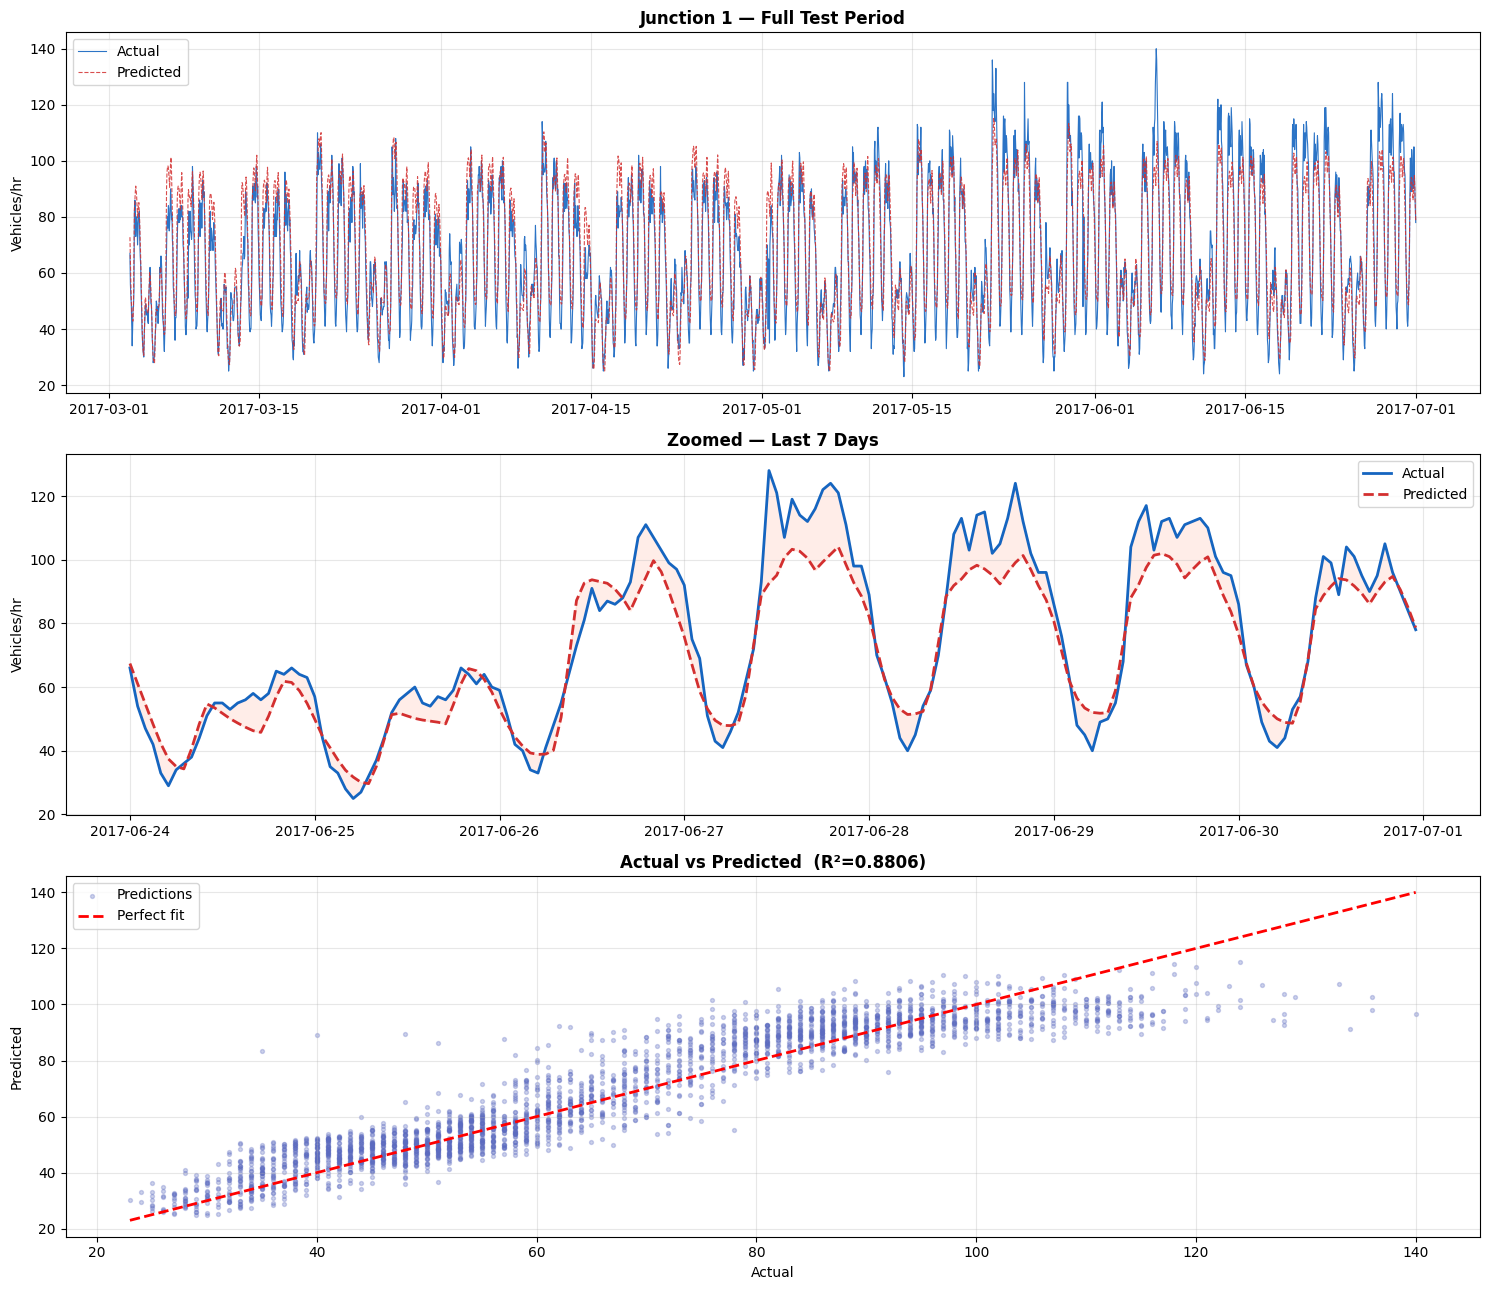

In [8]:
# Inverse-transform to original vehicle counts
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true = scaler_y.inverse_transform(y_test).flatten()
y_pred = np.maximum(y_pred, 0)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

print("=" * 46)
print(f"  LSTM — Junction {JUNCTION_TO_TRAIN} Performance")
print("=" * 46)
print(f"  MAE   : {mae:.2f}  vehicles/hour")
print(f"  RMSE  : {rmse:.2f}  vehicles/hour")
print(f"  R²    : {r2:.4f}  (1.0 = perfect)")
print(f"  MAPE  : {mape:.2f}%")
print("=" * 46)

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 13))

# Full test period
axes[0].plot(test_dates, y_true,  label='Actual',    color='#1565C0', linewidth=0.8, alpha=0.9)
axes[0].plot(test_dates, y_pred,  label='Predicted', color='#D32F2F', linewidth=0.8, alpha=0.85, linestyle='--')
axes[0].set_title(f'Junction {JUNCTION_TO_TRAIN} — Full Test Period', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Vehicles/hr'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Zoomed: last 7 days
N = 168
axes[1].plot(test_dates[-N:], y_true[-N:], label='Actual',    color='#1565C0', linewidth=2)
axes[1].plot(test_dates[-N:], y_pred[-N:], label='Predicted', color='#D32F2F', linewidth=2, linestyle='--')
axes[1].fill_between(test_dates[-N:], y_true[-N:], y_pred[-N:], alpha=0.12, color='#FF7043')
axes[1].set_title('Zoomed — Last 7 Days', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Vehicles/hr'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Scatter: actual vs predicted
axes[2].scatter(y_true, y_pred, alpha=0.3, color='#5C6BC0', s=8, label='Predictions')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[2].plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
axes[2].set_title(f'Actual vs Predicted  (R²={r2:.4f})', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Actual'); axes[2].set_ylabel('Predicted')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 🔁 Step 6b — Train All 4 Junctions (Optional)

Run this cell to train and evaluate a model for **every junction** at once.
Results are shown in a comparison table.


In [9]:
all_results = {}
all_models  = {}

for junc in sorted(df_feat['Junction'].unique()):
    print(f"\n── Training Junction {junc} ──")
    jdf_j = df_feat[df_feat['Junction'] == junc].copy()
    X_j, y_j, sc_X, sc_y = prepare_sequences(jdf_j, FEATURE_COLS, LOOKBACK)

    sp = int(len(X_j) * 0.80)
    Xtr, Xte = X_j[:sp], X_j[sp:]
    ytr, yte = y_j[:sp], y_j[sp:]

    m = build_lstm((LOOKBACK, len(FEATURE_COLS)))
    cb = [EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=0),
          ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)]
    m.fit(Xtr, ytr, validation_data=(Xte, yte),
          epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=cb, verbose=0)

    yp = sc_y.inverse_transform(m.predict(Xte, verbose=0)).flatten()
    yt = sc_y.inverse_transform(yte).flatten()
    yp = np.maximum(yp, 0)

    all_results[junc] = {
        'MAE' : round(mean_absolute_error(yt, yp), 2),
        'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 2),
        'R2'  : round(r2_score(yt, yp), 4),
        'MAPE': round(np.mean(np.abs((yt-yp)/(yt+1e-6)))*100, 2),
        'y_true': yt, 'y_pred': yp,
        'scaler_y': sc_y,
    }
    all_models[junc] = m
    print(f"   Junction {junc}  MAE={all_results[junc]['MAE']}  R²={all_results[junc]['R2']}")

# Summary table
summary = pd.DataFrame({j: {k: v for k, v in r.items()
                             if k in ('MAE','RMSE','R2','MAPE')}
                        for j, r in all_results.items()}).T
print("\n── Summary ──")
print(summary.to_string())



── Training Junction 1 ──
   Junction 1  MAE=7.21  R²=0.8218

── Training Junction 2 ──
   Junction 2  MAE=3.04  R²=0.7692

── Training Junction 3 ──
   Junction 3  MAE=4.28  R²=0.513

── Training Junction 4 ──
   Junction 4  MAE=2.82  R²=0.1656

── Summary ──
    MAE   RMSE      R2   MAPE
1  7.21  10.01  0.8218  10.31
2  3.04   3.98  0.7692  13.39
3  4.28   7.30  0.5130  24.32
4  2.82   3.91  0.1656  46.97


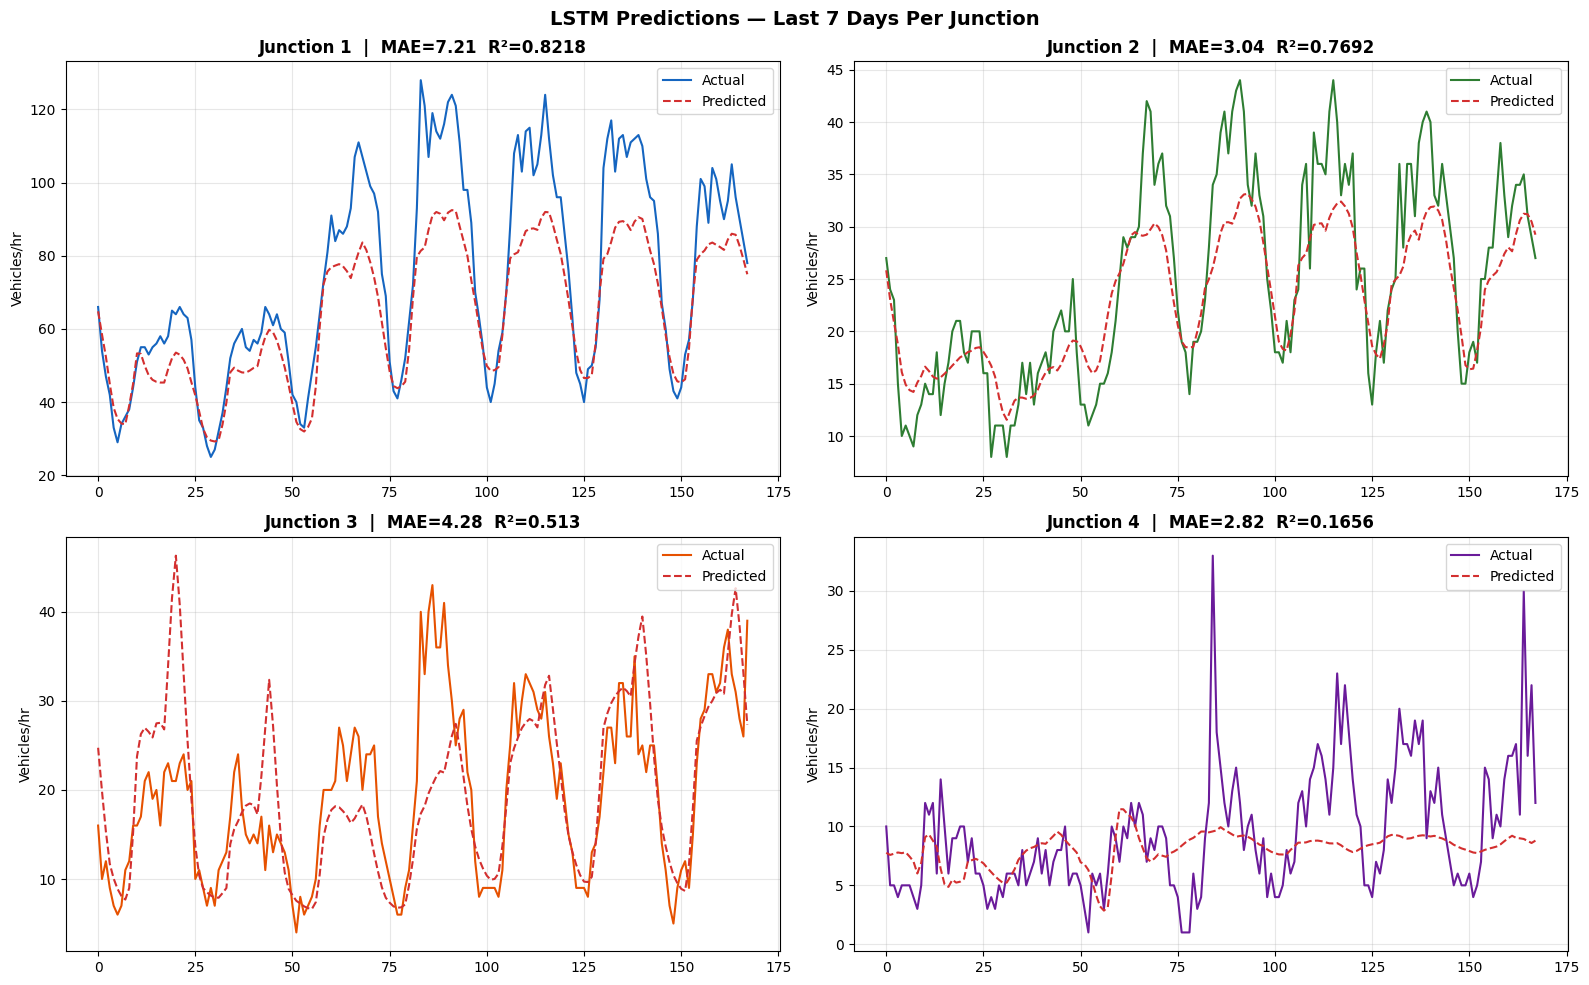

In [10]:
# Compare predictions across all junctions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

for i, junc in enumerate(sorted(all_results.keys())):
    r = all_results[junc]
    N = min(168, len(r['y_true']))
    axes[i].plot(r['y_true'][-N:], label='Actual',    color=colors[i],  linewidth=1.5)
    axes[i].plot(r['y_pred'][-N:], label='Predicted', color='#D32F2F',  linewidth=1.5, linestyle='--')
    axes[i].set_title(f"Junction {junc}  |  MAE={r['MAE']}  R²={r['R2']}",
                      fontweight='bold')
    axes[i].set_ylabel('Vehicles/hr'); axes[i].legend(); axes[i].grid(alpha=0.3)

plt.suptitle('LSTM Predictions — Last 7 Days Per Junction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 🔮 Step 7 — Forecast Next 24 Hours

Uses the last `LOOKBACK` hours of real data as the seed, then rolls
forward one step at a time — each prediction feeds back as input.


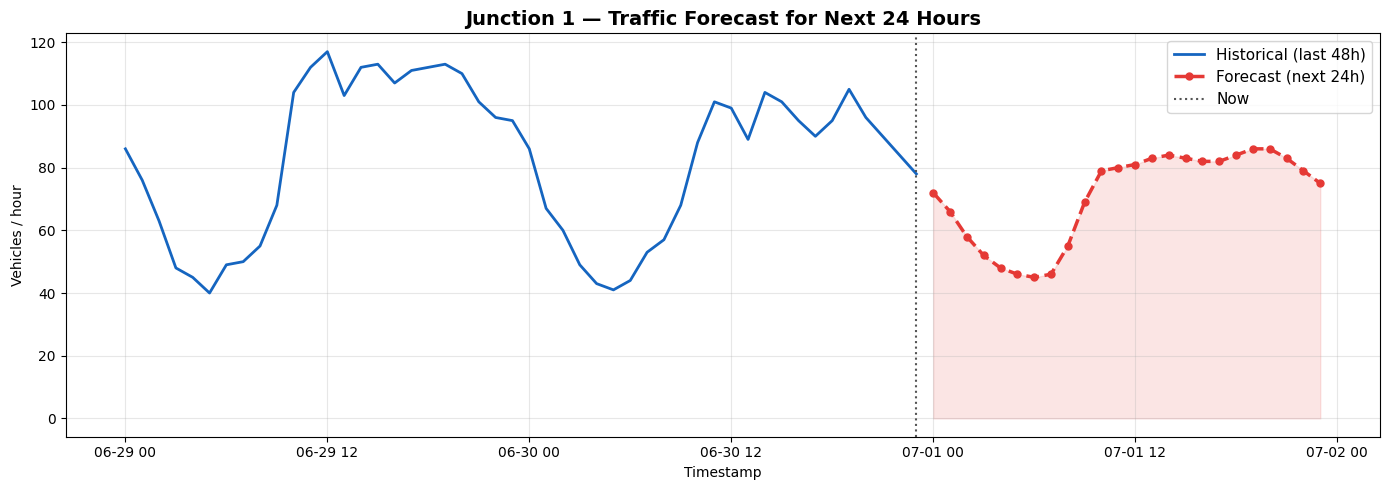


📋 Forecast table — Junction 1:
          timestamp  predicted_vehicles
2017-07-01 00:00:00                  72
2017-07-01 01:00:00                  66
2017-07-01 02:00:00                  58
2017-07-01 03:00:00                  52
2017-07-01 04:00:00                  48
2017-07-01 05:00:00                  46
2017-07-01 06:00:00                  45
2017-07-01 07:00:00                  46
2017-07-01 08:00:00                  55
2017-07-01 09:00:00                  69
2017-07-01 10:00:00                  79
2017-07-01 11:00:00                  80
2017-07-01 12:00:00                  81
2017-07-01 13:00:00                  83
2017-07-01 14:00:00                  84
2017-07-01 15:00:00                  83
2017-07-01 16:00:00                  82
2017-07-01 17:00:00                  82
2017-07-01 18:00:00                  84
2017-07-01 19:00:00                  86
2017-07-01 20:00:00                  86
2017-07-01 21:00:00                  83
2017-07-01 22:00:00                  79
2017-07-

In [11]:
FORECAST_JUNCTION = 1   # ← which junction to forecast
HOURS_AHEAD       = 24  # ← how many hours to predict

def forecast_future(model, df_feat, junction, feature_cols, lookback,
                    scaler_X, scaler_y, hours_ahead=24):
    jdf = df_feat[df_feat['Junction'] == junction].copy().reset_index(drop=True)

    # Seed: last `lookback` hours of real scaled data
    seed_X = scaler_X.transform(jdf[feature_cols].tail(lookback + hours_ahead))
    history_veh = list(jdf['Vehicles'].values)
    last_ts     = jdf['DateTime'].iloc[-1]

    preds = []
    window = seed_X[:lookback].tolist()   # initial window

    for h in range(hours_ahead):
        x_in = np.array(window[-lookback:]).reshape(1, lookback, len(feature_cols))
        pred_scaled = model.predict(x_in, verbose=0)[0][0]
        pred_veh    = float(scaler_y.inverse_transform([[pred_scaled]])[0][0])
        pred_veh    = max(0, pred_veh)

        next_ts = last_ts + pd.Timedelta(hours=h+1)
        preds.append({'timestamp': next_ts, 'predicted_vehicles': round(pred_veh)})
        history_veh.append(pred_veh)

        # Build next feature row using predicted vehicle count
        # Use seed_X row if available, else reuse last
        if (lookback + h) < len(seed_X):
            next_row = seed_X[lookback + h].copy()
        else:
            next_row = seed_X[-1].copy()
        window.append(next_row)

    return pd.DataFrame(preds)

# Use model trained in Step 5 (single junction) or all_models (Step 6b)
use_model = all_models.get(FORECAST_JUNCTION, model)

jdf_f = df_feat[df_feat['Junction'] == FORECAST_JUNCTION].copy()
_, _, sc_X_f, sc_y_f = prepare_sequences(jdf_f, FEATURE_COLS, LOOKBACK)

forecast_df = forecast_future(use_model, df_feat, FORECAST_JUNCTION,
                               FEATURE_COLS, LOOKBACK, sc_X_f, sc_y_f,
                               hours_ahead=HOURS_AHEAD)

# ── Plot ──────────────────────────────────────────────────────────────────
context = df_feat[df_feat['Junction'] == FORECAST_JUNCTION].tail(48)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(context['DateTime'], context['Vehicles'],
        label='Historical (last 48h)', color='#1565C0', linewidth=2)
ax.plot(forecast_df['timestamp'], forecast_df['predicted_vehicles'],
        label=f'Forecast (next {HOURS_AHEAD}h)', color='#E53935',
        linewidth=2.5, linestyle='--', marker='o', markersize=5)
ax.axvline(x=context['DateTime'].iloc[-1], color='#555', linestyle=':', linewidth=1.5, label='Now')
ax.fill_between(forecast_df['timestamp'], forecast_df['predicted_vehicles'],
                alpha=0.13, color='#E53935')
ax.set_title(f'Junction {FORECAST_JUNCTION} — Traffic Forecast for Next {HOURS_AHEAD} Hours',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Vehicles / hour'); ax.set_xlabel('Timestamp')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n📋 Forecast table — Junction {FORECAST_JUNCTION}:")
print(forecast_df.to_string(index=False))


## 💾 Step 8 — Save & Download the Model

In [13]:
# Save the single-junction model trained in Step 5
MODEL_FILE = f'traffic_lstm_junction{JUNCTION_TO_TRAIN}.keras'
model.save(MODEL_FILE)
print(f"✅ Model saved: {MODEL_FILE}")

# Download to your computer
from google.colab import files
files.download(MODEL_FILE)

# ── Also save all junction models if Step 6b was run ──
# for junc, m in all_models.items():
#     fname = f'traffic_lstm_junction{junc}.keras'
#     m.save(fname)
#     files.download(fname)

# ── Load the model later ──
# from tensorflow.keras.models import load_model
# model_loaded = load_model('traffic_lstm_junction1.keras')


✅ Model saved: traffic_lstm_junction1.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 💡 Tips to Improve Accuracy

| Technique | How |
|---|---|
| **Longer lookback** | Set `LOOKBACK = 48` or `168` (1 week) |
| **Tune architecture** | Add a 3rd LSTM layer or increase units to 256 |
| **Add weather data** | Merge temperature/rain as extra columns |
| **Holiday flags** | `pip install holidays` → add `is_holiday` column |
| **Hyperparameter search** | Use `keras_tuner` for automated tuning |
| **Multi-output model** | Predict all 4 junctions simultaneously |

### Load your saved model
```python
from tensorflow.keras.models import load_model
model = load_model('traffic_lstm_junction1.keras')
```

### Use the model in production
```python
# Given a new DataFrame with the last 24 hours of data:
X_new = scaler_X.transform(new_df[FEATURE_COLS])
X_new = X_new.reshape(1, LOOKBACK, len(FEATURE_COLS))
pred  = scaler_y.inverse_transform(model.predict(X_new))[0][0]
print(f"Predicted vehicles next hour: {pred:.0f}")
```


In [15]:
# ═══════════════════════════════════════════════════════════════
# STEP 9 — Save All Plots & Download as ZIP
# ═══════════════════════════════════════════════════════════════
import os
import zipfile
from google.colab import files

SAVE_DIR = "traffic_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

def save(fig, filename):
    path = os.path.join(SAVE_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  ✅ Saved: {filename}")

print("🎨 Regenerating and saving all plots...\n")

# ── Plot 1: Full history — all 4 junctions ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
junctions = sorted(df['Junction'].unique())
colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
for i, junc in enumerate(junctions):
    jdf = df[df['Junction'] == junc].copy()
    axes[i].plot(jdf['DateTime'], jdf['Vehicles'],
                 linewidth=0.5, color=colors[i], alpha=0.8)
    axes[i].set_title(f'Junction {junc}  |  avg={jdf["Vehicles"].mean():.1f}  max={jdf["Vehicles"].max()}',
                      fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Vehicles / hour')
    axes[i].grid(alpha=0.3)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[i].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=30)
fig.suptitle('Traffic Volume — All 4 Junctions (Full History)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
save(fig, "01_full_history_all_junctions.png")

# ── Plot 2: Hourly + daily patterns ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
for i, junc in enumerate(junctions):
    jdf = df[df['Junction'] == junc]
    hourly = jdf.groupby('hour')['Vehicles'].mean()
    axes[0].plot(hourly.index, hourly.values,
                 label=f'Junction {junc}', color=colors[i], linewidth=2)
    daily = jdf.groupby('day_of_week')['Vehicles'].mean()
    axes[1].plot(days, daily.values,
                 label=f'Junction {junc}', color=colors[i], linewidth=2, marker='o')
axes[0].axvspan(7, 9, alpha=0.1, color='red')
axes[0].axvspan(17, 19, alpha=0.1, color='orange')
axes[0].set_title('Average Traffic by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Avg Vehicles')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Average Traffic by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Avg Vehicles')
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
save(fig, "02_hourly_and_daily_patterns.png")

# ── Plot 3: Training curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train Loss', color='#1565C0')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#D32F2F')
axes[0].set_title('Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['mae'],     label='Train MAE', color='#1565C0')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#D32F2F')
axes[1].set_title('MAE', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
save(fig, "03_training_curves.png")

# ── Plot 4: Full test period predictions ────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(test_dates, y_true, label='Actual',    color='#1565C0', linewidth=0.8, alpha=0.9)
ax.plot(test_dates, y_pred, label='Predicted', color='#D32F2F', linewidth=0.8, alpha=0.85, linestyle='--')
ax.set_title(f'Junction {JUNCTION_TO_TRAIN} — Full Test Period', fontweight='bold', fontsize=12)
ax.set_ylabel('Vehicles/hr'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
save(fig, "04_predictions_full_test.png")

# ── Plot 5: Zoomed last 7 days ───────────────────────────────────
N = 168
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(test_dates[-N:], y_true[-N:], label='Actual',    color='#1565C0', linewidth=2)
ax.plot(test_dates[-N:], y_pred[-N:], label='Predicted', color='#D32F2F', linewidth=2, linestyle='--')
ax.fill_between(test_dates[-N:], y_true[-N:], y_pred[-N:], alpha=0.12, color='#FF7043')
ax.set_title('Zoomed — Last 7 Days', fontweight='bold', fontsize=12)
ax.set_ylabel('Vehicles/hr'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
save(fig, "05_predictions_last_7days.png")

# ── Plot 6: Actual vs predicted scatter ─────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, alpha=0.3, color='#5C6BC0', s=8)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
ax.set_title(f'Actual vs Predicted  (R²={r2:.4f})', fontweight='bold', fontsize=12)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
save(fig, "06_actual_vs_predicted_scatter.png")

# ── Plot 7: All junctions comparison ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, junc in enumerate(sorted(all_results.keys())):
    r = all_results[junc]
    N = min(168, len(r['y_true']))
    axes[i].plot(r['y_true'][-N:], label='Actual',    color=colors[i], linewidth=1.5)
    axes[i].plot(r['y_pred'][-N:], label='Predicted', color='#D32F2F', linewidth=1.5, linestyle='--')
    axes[i].set_title(f"Junction {junc}  |  MAE={r['MAE']}  R²={r['R2']}", fontweight='bold')
    axes[i].set_ylabel('Vehicles/hr'); axes[i].legend(); axes[i].grid(alpha=0.3)
fig.suptitle('LSTM Predictions — Last 7 Days Per Junction', fontsize=14, fontweight='bold')
fig.tight_layout()
save(fig, "07_all_junctions_comparison.png")

# ── Plot 8: Forecast next 24 hours (original forecast_df) ───────
context = df_feat[df_feat['Junction'] == FORECAST_JUNCTION].tail(48)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(context['DateTime'], context['Vehicles'],
        label='Historical (last 48h)', color='#1565C0', linewidth=2)
ax.plot(forecast_df['timestamp'], forecast_df['predicted_vehicles'],
        label=f'Forecast (next 24h)', color='#E53935',
        linewidth=2.5, linestyle='--', marker='o', markersize=5)
ax.axvline(x=context['DateTime'].iloc[-1], color='#555',
           linestyle=':', linewidth=1.5, label='Now')
ax.fill_between(forecast_df['timestamp'], forecast_df['predicted_vehicles'],
                alpha=0.13, color='#E53935')
ax.set_title(f'Junction {FORECAST_JUNCTION} — Traffic Forecast Next 24 Hours',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Vehicles / hour'); ax.set_xlabel('Timestamp')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
fig.tight_layout()
save(fig, "08_forecast_next_24h.png")

# ── ZIP & download ───────────────────────────────────────────────
ZIP_NAME = "traffic_plots.zip"
with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(os.listdir(SAVE_DIR)):
        if fname.endswith(".png"):
            zf.write(os.path.join(SAVE_DIR, fname), fname)

print(f"\n📦 Zipped {len(os.listdir(SAVE_DIR))} plots → {ZIP_NAME}")
print("⬇️  Downloading...")
files.download(ZIP_NAME)

🎨 Regenerating and saving all plots...

  ✅ Saved: 01_full_history_all_junctions.png
  ✅ Saved: 02_hourly_and_daily_patterns.png
  ✅ Saved: 03_training_curves.png
  ✅ Saved: 04_predictions_full_test.png
  ✅ Saved: 05_predictions_last_7days.png
  ✅ Saved: 06_actual_vs_predicted_scatter.png
  ✅ Saved: 07_all_junctions_comparison.png
  ✅ Saved: 08_forecast_next_24h.png

📦 Zipped 8 plots → traffic_plots.zip
⬇️  Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>